In [1]:
import networkx as nx
import random
import numpy as np
import pandas as pd
import multiprocessing
import functools
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import itertools
from scipy.stats import norm
from SIR_adaptive_net_ import *

Using 2 cores


In [ ]:
pairs_correct = []
dict_correct = {}
n = 500
ped = 0.05

In [119]:
nn = 200
epidemics = 10
iterations = 200

In [116]:
"""
To check:
0.08, 10 DONE
0.07, 10 DONE
0.05, 10 DONE
0.03, 15 DONE
0.02, 20 DONE
0.01, 30 DONE
"""

'\nTo check:\n0.08, 10 DONE\n0.07, 10 DONE\n0.05, 10\n0.03, 15\n0.02, 20 DONE\n0.01, 30 \n'

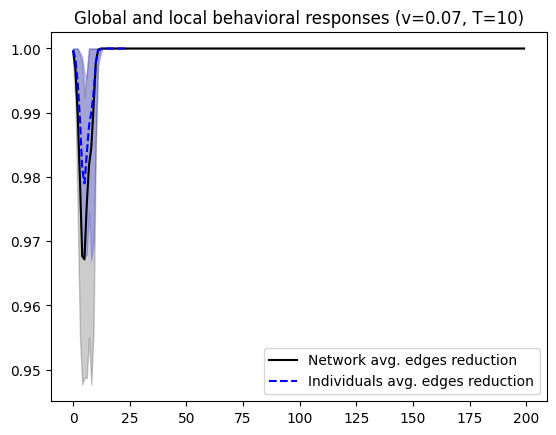

In [152]:
v = 0.07
T = 10
net = nx.gnp_random_graph(n, ped)
bepidist_example = bepisim(ntwk=net,
                   epidemics=epidemics,
                   iterations=iterations,
                   dispars=[0.05, 0.04],
                   u=[v, T], neis=1, n=n)
bepidist_example['V'] = v
bepidist_example['T'] = T
plt.figure()
plt.plot(bepidist_example['edgecount_mean'][0:nn],'-k', label="Network avg. edges reduction")
plt.fill_between(range(nn), bepidist_example['edgecount_min'][0:nn], bepidist_example['edgecount_max'][0:nn], color="k", alpha=0.2)
plt.plot(bepidist_example['suscedgecount_mean'][0:nn], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(range(nn), bepidist_example['suscedgecount_min'][0:nn], bepidist_example['suscedgecount_max'][0:nn], color="blue", alpha=0.2)
plt.title(f"Global and local behavioral responses (v={v}, T={T})")
plt.legend(loc="lower right")
plt.show()

In [147]:
if (v,T) not in pairs_correct:
    pairs_correct.append((v,T))
dict_correct[(v,T)] = bepidist_example

In [148]:
print(dict_correct.keys())
pairs_correct

dict_keys([(0.08, 10), (0.07, 10), (0.02, 20), (0.01, 30), (0.1, 35), (0.03, 15), (0.05, 10), (0.01, 25), (0.1, 5)])


[(0.08, 10),
 (0.07, 10),
 (0.02, 20),
 (0.01, 30),
 (0.1, 35),
 (0.03, 15),
 (0.05, 10),
 (0.01, 25),
 (0.1, 5)]

In [149]:
bepidist_data = pd.read_csv('./Data/bepidist_check.csv')
bepidist_data = bepidist_data.apply(pd.to_numeric)

{11,11,12,11,8,8,7,7,8,9},
{12,11,9,12,0,0,0,0,1,0},
{12,11,1,0,0,0,0,0,0,0},
{10,0,0,0,0,0,0,0,0,0},
{7,0,0,0,0,0,0,0,0,0},
{0,1,0,0,0,0,0,0,0,0},
{1,0,0,0,0,0,0,0,0,0},


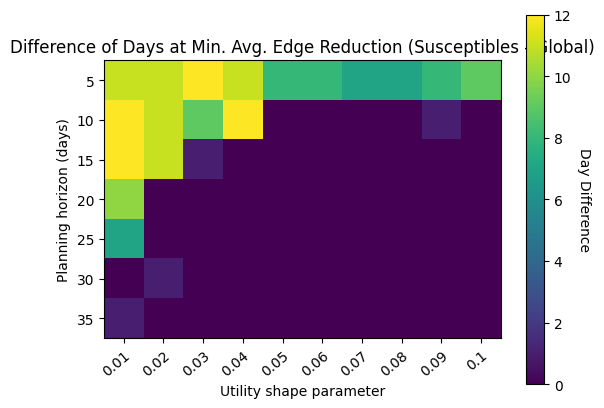

In [150]:
# ------- #
bepidist_data_corrected = pd.DataFrame({})

data_min = pd.DataFrame({})
for v in bepidist_data['V'].unique():
    for T in bepidist_data['T'].unique():

        if (v,T) in pairs_correct:
            bepidist = dict_correct[(v,T)] 
        else:
            bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

        bepidist_data_corrected = pd.concat([bepidist_data_corrected, bepidist])
        
        mean_ctc_ = bepidist['edgecount_mean'].tolist()
        min_ctc_day_ = np.nanargmin(mean_ctc_)
        
        mean_ctc_sus_ = bepidist['suscedgecount_mean'].tolist()
        min_ctc_day_sus_ = np.nanargmin(mean_ctc_sus_)
        
        day_lag_ = min_ctc_day_sus_ - min_ctc_day_
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [day_lag_]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Day Difference", rotation = -90, va = "bottom")
plt.title(f"Difference of Days at Min. Avg. Edge Reduction (Susceptibles - Global)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

In [151]:
bepidist_data_corrected.to_csv('./bepidist_data_corrected.csv')

In [ ]:
##### Reverse colormap
import matplotlib as mpl

def reverse_colourmap(cmap, name = 'my_cmap_r'):
    """
    In: 
    cmap, name 
    Out:
    my_cmap_r

    Explanation:
    t[0] goes from 0 to 1
    row i:   x  y0  y1 -> t[0] t[1] t[2]
                   /
                  /
    row i+1: x  y0  y1 -> t[n] t[1] t[2]

    so the inverse should do the same:
    row i+1: x  y1  y0 -> 1-t[0] t[2] t[1]
                   /
                  /
    row i:   x  y1  y0 -> 1-t[n] t[2] t[1]
    """        
    reverse = []
    k = []   

    for key in cmap._segmentdata:    
        k.append(key)
        channel = cmap._segmentdata[key]
        data = []

        for t in channel:                    
            data.append((1-t[0],t[2],t[1]))            
        reverse.append(sorted(data))    

    LinearL = dict(zip(k,reverse))
    my_cmap_r = mpl.colors.LinearSegmentedColormap(name, LinearL) 
    return my_cmap_r
cmap = mpl.cm.YlOrRd
cmap_r = reverse_colourmap(cmap)   